In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import itertools as it
from pathlib import Path
import matplotlib.pylab as plt
from lameg.util import get_files, get_bigbrain_layer_boundaries
import nibabel as nib
from scipy.spatial.distance import euclidean
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec

In [2]:
plt.rcParams.update({
    'font.size': 16,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [3]:
def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')


In [4]:
subj_id='sub-001'
subj_surf_dir=f'/home/common/bonaiuto/cued_action_meg/derivatives/processed/{subj_id}/surf'
n_layers = 11
layers = np.arange(n_layers)
vx_loc, vx_adj, surf_norm = nib.load(os.path.join(subj_surf_dir, "multilayer.11.ds.link_vector.fixed.gii")).agg_data()
layers_loc = np.array(np.split(vx_loc, n_layers, axis=0))
cortical_thickness = np.array([euclidean(layers_loc[0, i, :], layers_loc[-1, i, :]) for i in range(layers_loc.shape[1])])

In [5]:
snr_res = Path("../output/snr_simulations/")
snr_files = get_files(snr_res, "*.pickle")

In [6]:
def annotate_mx(im, txt_mx, **textkw):
    kw = dict(
        horizontalalignment="center",
        verticalalignment="center"
    )
    kw.update(textkw)
    for r, c in it.product(range(txt_mx.shape[0]), range(txt_mx.shape[1])):
        im.axes.text(c, r, txt_mx[r, c], **kw)

def colorbar(mappable, label):
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax, label=label)
    plt.sca(last_axes)
    return cbar


def plot_mx(mx, title="", ax=False, labels=False, cbar=False, cmap="Spectral_r", norm=False, cbar_label=r"$\Delta$ FE"):
    if not ax:
        f, ax = plt.subplots(1, 1)
    else:
        ax = ax
    if not norm:
        iw = ax.imshow(mx, cmap=cmap)
    else:
        iw = ax.imshow(mx, cmap=cmap, norm=norm)
    if labels:
        ax.set_ylabel("Evaluation")
        ax.set_xlabel("Simulation")
        ax.set_xticks([0,n_layers-1])
        ax.set_xticklabels(['S','D'])
        ax.set_yticks([0,n_layers-1])
        ax.set_yticklabels(['S','D'])
        plt.suptitle(title)
        plt.tight_layout()
    if cbar:
        colorbar(iw, cbar_label)
    return iw


def norm_res(mx):
    norm = np.zeros(mx.shape)
    for l in range(mx.shape[1]):
        normed = mx[:,l] - np.min(mx[:,l])
        norm[:,l] = normed
    return norm


def find_peaks(mx, marker="*", return_annot=True):
    annot = np.zeros(mx.shape).astype(np.object_)
    peaks = []
    for l in range(mx.shape[1]):
        peak = np.argmax(mx[:, l]) # here is the problem (you find peak in evaluated!)
        annot[peak,l] = 1.0
        peaks.append(peak)
    peaks = np.array(peaks)
    annot_bin = np.copy(annot).astype(float)
    annot[annot==0.0] = None
    annot[annot==1.0] = marker
    if return_annot:
        return peaks, annot, annot_bin
    else:
        return peaks

def bootstrap_func(data, n_boot=1000, prop=0.5, func="mean"):
    n_rows = data.shape[0]
    rows = np.arange(n_rows)
    prop_rows = int(n_rows*prop)
    results = []
    for b in range(n_boot):
        boot_rows = np.random.choice(rows, size=prop_rows)
        if func == "mean":
            results.append(data[boot_rows].mean(axis=0))
        elif func == "sem":
            results.append(data[boot_rows].std(axis=0) / np.sqrt(prop_rows))
    return np.array(results)


def bootstrap(data, n_boot=1000, prop=0.5):
    n_rows = data.shape[0]
    rows = np.arange(n_rows)
    prop_rows = int(n_rows*prop)
    results = []
    for b in range(n_boot):
        boot_rows = np.random.choice(rows, size=prop_rows)
        results.append(data[boot_rows])
    return np.array(results)


def shuffled_peak_error(mx, ab=False):
    mx_sh = shuffle_mx(mx)
    peaks = find_peaks(mx_sh, return_annot=False)
    peaks = peaks - np.arange(mx.shape[0])
    if not ab:
        return peaks
    else:
        return np.abs(peaks)


def shuffle_mx(mx):
    mx_shape = mx.shape
    mx = mx.flatten()
    np.random.shuffle(mx)
    return mx.reshape(mx_shape)

In [7]:
fnms = np.array([[i] + i.stem.split("_") for i in snr_files])
map_fnms = np.array([i in [1, 3, 5, 6] for i in range(7)])
fnms = fnms[:,~map_fnms]
names_ = ["filename", "vx", "snr"]
df_files = pd.DataFrame.from_dict(
    {k: fnms[:,i] for i, k in enumerate(names_)}
)
df_files["matrix"] = None
df_files.vx = df_files.vx.apply(lambda x: eval(x))
df_files.snr = df_files.snr.apply(lambda x: eval(x))
mxs = []
for ix, row in df_files.iterrows():
    with open(row.filename, "rb") as file:
        output = pickle.load(file)
    output = output["layerF"]
    df_files.at[ix, "matrix"] = output

In [8]:
vertices = df_files.vx.unique()
vertices.sort()
snrs = df_files.snr.unique()
snrs.sort()

In [9]:
matrices_all = {i: [] for i in snrs}
annots_bin = {i: [] for i in snrs}

for vx in vertices:
    for snr_ix, snr in enumerate(snrs):
        row = df_files.loc[
            (df_files.vx == vx) &
            (df_files.snr == snr)
        ]
        mx = row.matrix.values[0]
        mx = norm_res(mx)
        peaks, annot, annot_bin = find_peaks(mx, marker=r"$\wedge$")
        
        matrices_all[snr].append(mx)
        annots_bin[snr].append(annot_bin)

In [10]:
snr_res = Path("../output/snr_simulations/")
snr_files = get_files(snr_res, "*.pickle")
fnms = np.array([[i] + i.stem.split("_") for i in snr_files])
map_fnms = np.array([i in [1, 3, 5, 6] for i in range(7)])
fnms = fnms[:,~map_fnms]
names_ = ["filename", "vx", "snr"]
snr_files = pd.DataFrame.from_dict(
    {k: fnms[:,i] for i, k in enumerate(names_)}
)
snr_files["matrix"] = None
snr_files["norm_matrix"] = None
snr_files["peaks"] = None
snr_files["cortical_thickness"] = None
snr_files["error"] = None
snr_files["bias"] = None
snr_files["sum_error"] = None
snr_files["sum_error_mm"] = None
snr_files["error_mm"] = None
snr_files["bias_mm"] = None
snr_files["simulated_laminae"] = None
snr_files["peak_laminae"] = None
snr_files["surf_bb_bounds"] = None
snr_files.vx = snr_files.vx.apply(lambda x: eval(x))
snr_files.snr = snr_files.snr.apply(lambda x: eval(x))
mxs = []
for ix, row in snr_files.iterrows():
    with open(row.filename, "rb") as file:
        output = pickle.load(file)
    output = output["layerF"]
    snr_files.at[ix, "matrix"] = output
    mx = norm_res(output)
    snr_files.at[ix, "norm_matrix"] = mx
    peaks, annot, annot_bin = find_peaks(mx, marker=r"$\wedge$")
    layer_multiplier = cortical_thickness[row.vx] / n_layers
    snr_files.at[ix, "peaks"] = peaks
    snr_files.at[ix, "cortical_thickness"] = cortical_thickness[row.vx]
    snr_files.at[ix, "error"] = np.abs(layers - peaks)
    snr_files.at[ix, "bias"] = layers - peaks
    snr_files.at[ix, "error_mm"] = np.mean(np.abs(layers * layer_multiplier - peaks * layer_multiplier))
    snr_files.at[ix, "bias_mm"] = np.mean(layers * layer_multiplier - peaks * layer_multiplier)
    snr_files.at[ix, "sum_error"] = np.sum(np.abs(layers - peaks))
    snr_files.at[ix, "sum_error_mm"] = np.sum(np.abs(layers * layer_multiplier - peaks * layer_multiplier))
    
    coord=vx_loc[row.vx,:]
    vert_bb_prop=get_bigbrain_layer_boundaries(subj_id, subj_surf_dir, coord)
    surf_bb_bounds=(n_layers*vert_bb_prop)
    snr_files.at[ix, "surf_bb_bounds"] = surf_bb_bounds
    snr_files.at[ix, "simulated_laminae"] = np.digitize(np.arange(n_layers), surf_bb_bounds)
    snr_files.at[ix, "peak_laminae"] = np.digitize(peaks, surf_bb_bounds)

In [11]:
snr_range = snr_files.snr.unique()
snr_range.sort()
snr_files.columns

Index(['filename', 'vx', 'snr', 'matrix', 'norm_matrix', 'peaks',
       'cortical_thickness', 'error', 'bias', 'sum_error', 'sum_error_mm',
       'error_mm', 'bias_mm', 'simulated_laminae', 'peak_laminae',
       'surf_bb_bounds'],
      dtype='object')

In [12]:
n_permutations = 10000

snr_error_lines = {x: [] for x in range(6)}
snr_error_res = {x: [] for x in range(6)}
snr_shuf_error_res = {x: [] for x in range(6)}
snr_p_values_error = {x: [] for x in range(6)}
snr_effect_sizes_error = {x: [] for x in range(6)}

for snr in snr_range:
    matrices = snr_files.loc[snr_files.snr == snr].norm_matrix.values.tolist()
    simulated_lam=np.array(snr_files.loc[snr_files.snr==snr].simulated_laminae.values.tolist()).reshape(-1,1)
    peak_lam=np.array(snr_files.loc[snr_files.snr==snr].peak_laminae.values.tolist()).reshape(-1,1)
    
    surf_bb_bounds=snr_files.loc[snr_files.snr==snr].surf_bb_bounds.values.tolist()
    for l in range(6):
        s_idx=np.where(simulated_lam==l)[0]
        
        error=np.abs(peak_lam[s_idx]-l)
        
        error_bs = np.mean(bootstrap(error, n_boot=5000), axis=1)

        permuted_error = np.zeros(n_permutations)
        for idx in range(n_permutations):
            permuted_peaks=[]
            for mat_idx, mat in enumerate(matrices):
                mx_sh = shuffle_mx(mat)
                peaks = find_peaks(mx_sh, return_annot=False)
                p_peak_lam = np.digitize(peaks, surf_bb_bounds[mat_idx])
                permuted_peaks.append(p_peak_lam)
            permuted_peaks=np.hstack(permuted_peaks)
            permuted_error[idx]=np.mean(np.abs(permuted_peaks[s_idx]-l))
    
        # Compute p-values
        p_value_error = (np.sum(permuted_error < np.mean(error)) + 1) / (n_permutations + 1)
    
        # Compute effect sizes (Cohen's d)
        effect_size_error = (np.mean(error) - np.mean(permuted_error)) / np.std(permuted_error, ddof=1)
    
        # mean 95% CI
        error_95ci = [np.percentile(error_bs, 2.5), np.percentile(error_bs, 97.5)]
        error_95ci_shuf = [np.percentile(permuted_error, 2.5), np.percentile(permuted_error, 97.5)]
    
        snr_error_lines[l].append(error)
        snr_error_res[l].append([np.mean(error)] + error_95ci)
        snr_shuf_error_res[l].append([np.mean(permuted_error)] + error_95ci_shuf)
        snr_p_values_error[l].append(p_value_error)
        snr_effect_sizes_error[l].append(effect_size_error)
    
for l in range(6):
    snr_error_lines[l] = np.array(snr_error_lines[l])
    snr_error_res[l] = np.array(snr_error_res[l])
    snr_shuf_error_res[l] = np.array(snr_shuf_error_res[l])
    snr_p_values_error[l] = np.array(snr_p_values_error[l])
    snr_effect_sizes_error[l] = np.array(snr_effect_sizes_error[l])

In [29]:
for idx, snr in enumerate(snr_range):
    for l in range(6):
        print(f'layer {l+1}, {snr} dB, error: d={snr_effect_sizes_error[l][idx]:.2f}, p={snr_p_values_error[l][idx]:.3f}')

layer 1, -500 dB, error: d=1.05, p=0.850
layer 2, -500 dB, error: d=3.22, p=0.999
layer 3, -500 dB, error: d=13.66, p=1.000
layer 4, -500 dB, error: d=8.26, p=1.000
layer 5, -500 dB, error: d=5.73, p=1.000
layer 6, -500 dB, error: d=1.58, p=0.939
layer 1, -100 dB, error: d=0.95, p=0.818
layer 2, -100 dB, error: d=2.78, p=0.997
layer 3, -100 dB, error: d=13.66, p=1.000
layer 4, -100 dB, error: d=8.02, p=1.000
layer 5, -100 dB, error: d=5.96, p=1.000
layer 6, -100 dB, error: d=1.13, p=0.865
layer 1, -50 dB, error: d=-11.94, p=0.000
layer 2, -50 dB, error: d=-3.77, p=0.000
layer 3, -50 dB, error: d=1.05, p=0.845
layer 4, -50 dB, error: d=-1.37, p=0.077
layer 5, -50 dB, error: d=-4.40, p=0.000
layer 6, -50 dB, error: d=-13.50, p=0.000
layer 1, -35 dB, error: d=-18.72, p=0.000
layer 2, -35 dB, error: d=-11.36, p=0.000
layer 3, -35 dB, error: d=-18.42, p=0.000
layer 4, -35 dB, error: d=-12.05, p=0.000
layer 5, -35 dB, error: d=-15.98, p=0.000
layer 6, -35 dB, error: d=-17.76, p=0.000
layer 1

In [14]:
coreg_res = Path("../output/coreg_err_simulations/")
coreg_files = get_files(coreg_res, "*.pickle")

In [15]:
fnms = np.array([[i] + i.stem.split("_") for i in coreg_files])
map_fnms = np.array([i in [1, 3, 5, 6] for i in range(7)])
fnms = fnms[:,~map_fnms]
names_ = ["filename", "vx", "coreg_error"]
df_files = pd.DataFrame.from_dict(
    {k: fnms[:,i] for i, k in enumerate(names_)}
)
df_files["matrix"] = None
df_files.vx = df_files.vx.apply(lambda x: eval(x))
df_files.coreg_error = df_files.coreg_error.apply(lambda x: eval(x))
mxs = []
for ix, row in df_files.iterrows():
    with open(row.filename, "rb") as file:
        output = pickle.load(file)
    output = output["layerF"]
    df_files.at[ix, "matrix"] = output

In [16]:
vertices = df_files.vx.unique()
vertices.sort()
coreg_errs = df_files.coreg_error.unique()
coreg_errs.sort()

In [17]:
matrices_all = {i: [] for i in coreg_errs}
annots_bin = {i: [] for i in coreg_errs}

for vx in vertices:
    for err_ix, cor_err in enumerate(coreg_errs):
        row = df_files.loc[
            (df_files.vx == vx) &
            (df_files.coreg_error == cor_err)
        ]
        mx = row.matrix.values[0]
        mx = norm_res(mx)
        peaks, annot, annot_bin = find_peaks(mx, marker=r"$\wedge$")
        
        matrices_all[cor_err].append(mx)
        annots_bin[cor_err].append(annot_bin)

In [18]:
coreg_res = Path("../output/coreg_err_simulations/")
coreg_files = get_files(coreg_res, "*.pickle")
fnms = np.array([[i] + i.stem.split("_") for i in coreg_files])
map_fnms = np.array([i in [1, 3, 5, 6] for i in range(7)])
fnms = fnms[:,~map_fnms]
names_ = ["filename", "vx", "coreg_error"]
coreg_files = pd.DataFrame.from_dict(
    {k: fnms[:,i] for i, k in enumerate(names_)}
)
coreg_files["matrix"] = None
coreg_files["norm_matrix"] = None
coreg_files["peaks"] = None
coreg_files["cortical_thickness"] = None
coreg_files["error"] = None
coreg_files["bias"] = None
coreg_files["sum_error"] = None
coreg_files["sum_error_mm"] = None
coreg_files["error_mm"] = None
coreg_files["bias_mm"] = None
coreg_files["simulated_laminae"] = None
coreg_files["peak_laminae"] = None
coreg_files["surf_bb_bounds"] = None
coreg_files.vx = coreg_files.vx.apply(lambda x: eval(x))
coreg_files.coreg_error = coreg_files.coreg_error.apply(lambda x: eval(x))
mxs = []
for ix, row in coreg_files.iterrows():
    with open(row.filename, "rb") as file:
        output = pickle.load(file)
    output = output["layerF"]
    coreg_files.at[ix, "matrix"] = output
    mx = norm_res(output)
    coreg_files.at[ix, "norm_matrix"] = mx
    peaks, annot, annot_bin = find_peaks(mx, marker=r"$\wedge$")
    layer_multiplier = cortical_thickness[row.vx] / n_layers
    coreg_files.at[ix, "peaks"] = peaks
    coreg_files.at[ix, "cortical_thickness"] = cortical_thickness[row.vx]
    coreg_files.at[ix, "error"] = np.abs(layers - peaks)
    coreg_files.at[ix, "bias"] = layers - peaks
    coreg_files.at[ix, "error_mm"] = np.mean(np.abs(layers * layer_multiplier - peaks * layer_multiplier))
    coreg_files.at[ix, "bias_mm"] = np.mean(layers * layer_multiplier - peaks * layer_multiplier)
    coreg_files.at[ix, "sum_error"] = np.sum(np.abs(layers - peaks))
    coreg_files.at[ix, "sum_error_mm"] = np.sum(np.abs(layers * layer_multiplier - peaks * layer_multiplier))
    
    coord=vx_loc[row.vx,:]
    vert_bb_prop=get_bigbrain_layer_boundaries(subj_id, subj_surf_dir, coord)
    surf_bb_bounds=(n_layers*vert_bb_prop)
    coreg_files.at[ix, "surf_bb_bounds"] = surf_bb_bounds
    coreg_files.at[ix, "simulated_laminae"] = np.digitize(np.arange(n_layers), surf_bb_bounds)
    coreg_files.at[ix, "peak_laminae"] = np.digitize(peaks, surf_bb_bounds)

In [19]:
coreg_range = coreg_files.coreg_error.unique()
coreg_range.sort()
coreg_files.columns

Index(['filename', 'vx', 'coreg_error', 'matrix', 'norm_matrix', 'peaks',
       'cortical_thickness', 'error', 'bias', 'sum_error', 'sum_error_mm',
       'error_mm', 'bias_mm', 'simulated_laminae', 'peak_laminae',
       'surf_bb_bounds'],
      dtype='object')

In [20]:
n_permutations = 10000

coreg_error_lines = {x: [] for x in range(6)}
coreg_error_res = {x: [] for x in range(6)}
coreg_shuf_error_res = {x: [] for x in range(6)}
coreg_p_values_error = {x: [] for x in range(6)}
coreg_effect_sizes_error = {x: [] for x in range(6)}

for coreg_error in coreg_range:
    matrices = coreg_files.loc[coreg_files.coreg_error == coreg_error].norm_matrix.values.tolist()
    simulated_lam=np.array(coreg_files.loc[coreg_files.coreg_error==coreg_error].simulated_laminae.values.tolist()).reshape(-1,1)
    peak_lam=np.array(coreg_files.loc[coreg_files.coreg_error==coreg_error].peak_laminae.values.tolist()).reshape(-1,1)
    
    surf_bb_bounds=coreg_files.loc[coreg_files.coreg_error==coreg_error].surf_bb_bounds.values.tolist()
    for l in range(6):
        s_idx=np.where(simulated_lam==l)[0]
        
        error=np.abs(peak_lam[s_idx]-l)
        
        error_bs = np.mean(bootstrap(error, n_boot=5000), axis=1)

        permuted_error = np.zeros(n_permutations)
        for idx in range(n_permutations):
            permuted_peaks=[]
            for mat_idx, mat in enumerate(matrices):
                mx_sh = shuffle_mx(mat)
                peaks = find_peaks(mx_sh, return_annot=False)
                p_peak_lam = np.digitize(peaks, surf_bb_bounds[mat_idx])
                permuted_peaks.append(p_peak_lam)
            permuted_peaks=np.hstack(permuted_peaks)
            permuted_error[idx]=np.mean(np.abs(permuted_peaks[s_idx]-l))
    
        # Compute p-values
        p_value_error = (np.sum(permuted_error < np.mean(error)) + 1) / (n_permutations + 1)
    
        # Compute effect sizes (Cohen's d)
        effect_size_error = (np.mean(error) - np.mean(permuted_error)) / np.std(permuted_error, ddof=1)
    
        # mean 95% CI
        error_95ci = [np.percentile(error_bs, 2.5), np.percentile(error_bs, 97.5)]
        error_95ci_shuf = [np.percentile(permuted_error, 2.5), np.percentile(permuted_error, 97.5)]
    
        coreg_error_lines[l].append(error)
        coreg_error_res[l].append([np.mean(error)] + error_95ci)
        coreg_shuf_error_res[l].append([np.mean(permuted_error)] + error_95ci_shuf)
        coreg_p_values_error[l].append(p_value_error)
        coreg_effect_sizes_error[l].append(effect_size_error)
    
for l in range(6):
    coreg_error_lines[l] = np.array(coreg_error_lines[l])
    coreg_error_res[l] = np.array(coreg_error_res[l])
    coreg_shuf_error_res[l] = np.array(coreg_shuf_error_res[l])
    coreg_p_values_error[l] = np.array(coreg_p_values_error[l])
    coreg_effect_sizes_error[l] = np.array(coreg_effect_sizes_error[l])

In [30]:
for idx, coreg_error in enumerate(coreg_range):
    for l in range(6):
        print(f'layer {l+1}, {coreg_error} mm, error: d={coreg_effect_sizes_error[l][idx]:.2f}, p={coreg_p_values_error[l][idx]:.3f}')

layer 1, 0.0 mm, error: d=-20.37, p=0.000
layer 2, 0.0 mm, error: d=-14.92, p=0.000
layer 3, 0.0 mm, error: d=-22.80, p=0.000
layer 4, 0.0 mm, error: d=-16.42, p=0.000
layer 5, 0.0 mm, error: d=-18.81, p=0.000
layer 6, 0.0 mm, error: d=-19.40, p=0.000
layer 1, 0.5 mm, error: d=-18.94, p=0.000
layer 2, 0.5 mm, error: d=-12.40, p=0.000
layer 3, 0.5 mm, error: d=-19.88, p=0.000
layer 4, 0.5 mm, error: d=-11.19, p=0.000
layer 5, 0.5 mm, error: d=-15.88, p=0.000
layer 6, 0.5 mm, error: d=-17.86, p=0.000
layer 1, 1.0 mm, error: d=-17.11, p=0.000
layer 2, 1.0 mm, error: d=-10.12, p=0.000
layer 3, 1.0 mm, error: d=-12.92, p=0.000
layer 4, 1.0 mm, error: d=-8.07, p=0.000
layer 5, 1.0 mm, error: d=-13.32, p=0.000
layer 6, 1.0 mm, error: d=-17.02, p=0.000
layer 1, 2.0 mm, error: d=-14.24, p=0.000
layer 2, 2.0 mm, error: d=-7.63, p=0.000
layer 3, 2.0 mm, error: d=-7.25, p=0.000
layer 4, 2.0 mm, error: d=-4.45, p=0.000
layer 5, 2.0 mm, error: d=-11.21, p=0.000
layer 6, 2.0 mm, error: d=-15.77, p=0.

In [22]:
snr_tick_labels = [f"{i}" for i in snr_range]
snr_tick_labels[0] = r"-$\infty$"
snr_ix = np.arange(snr_range.shape[0])
snr_ix[0] = snr_ix[0] - 1

In [23]:
coreg_tick_labels = [f"{i}" for i in coreg_range]
coreg_error_ix = np.arange(coreg_range.shape[0])

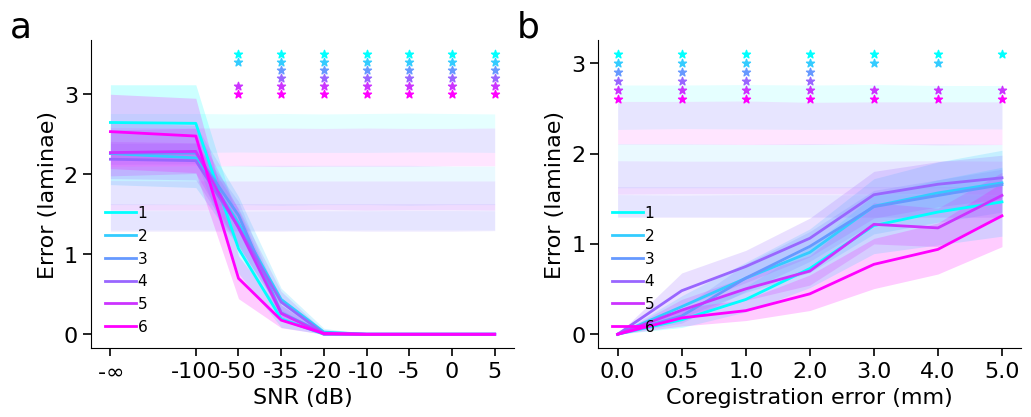

In [28]:
fig=plt.figure(figsize=(12,4))
ax=plt.subplot(1,2,1)
col_r = plt.cm.cool(np.linspace(0,1, num=6))
for l_idx in range(6):
    ax.plot(snr_ix, snr_error_res[l_idx][:,0], color=col_r[l_idx], lw=2, label=f'{l_idx+1}')
    ax.fill_between(snr_ix, snr_error_res[l_idx][:,1], snr_error_res[l_idx][:,2], color=col_r[l_idx], lw=0, alpha=0.2)
    ax.fill_between(snr_ix, snr_shuf_error_res[l_idx][:,1], snr_shuf_error_res[l_idx][:,2], color=col_r[l_idx], lw=0, alpha=0.1)
ax.set_xticks(snr_ix)
ax.set_xticklabels(snr_tick_labels)
ax.set_ylabel("Error (laminae)")
ax.set_xlabel("SNR (dB)")
ax.legend(fontsize="x-small", loc='lower left')
for l_idx in range(6):
    sig_levels=np.where(snr_p_values_error[l_idx]<0.05)[0]
    ax.scatter(snr_ix[sig_levels],np.tile(3+((5-l_idx)*.1),len(sig_levels)),marker='*',color=col_r[l_idx])
add_subplot_label(ax, 'a', x=-.14, y=1.1)

ax=plt.subplot(1,2,2)
col_r = plt.cm.cool(np.linspace(0,1, num=6))
for l_idx in range(6):
    ax.plot(coreg_error_ix, coreg_error_res[l_idx][:,0], color=col_r[l_idx], lw=2, label=f'{l_idx+1}')
    ax.fill_between(coreg_error_ix, coreg_error_res[l_idx][:,1], coreg_error_res[l_idx][:,2], color=col_r[l_idx], lw=0, alpha=0.2)
    ax.fill_between(coreg_error_ix, coreg_shuf_error_res[l_idx][:,1], coreg_shuf_error_res[l_idx][:,2], color=col_r[l_idx], lw=0, alpha=0.1)
ax.set_xticks(coreg_error_ix)
ax.set_xticklabels(coreg_tick_labels)
ax.set_ylabel("Error (laminae)")
ax.set_xlabel("Coregistration error (mm)")
ax.legend(fontsize="x-small", loc='lower left')
for l_idx in range(6):
    sig_levels=np.where(coreg_p_values_error[l_idx]<0.05)[0]
    ax.scatter(coreg_error_ix[sig_levels],np.tile(2.6+((5-l_idx)*.1),len(sig_levels)),marker='*',color=col_r[l_idx])
add_subplot_label(ax, 'b', x=-.14, y=1.1)
plt.savefig(f"figure_04_snr_coreg_error_laminae.pdf")